# XGBM & LGBM

### Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Titanic dataset
# If you have the file locally: df = pd.read_csv('titanic.csv')
# Or loading directly from seaborn's built-in library:
df = sns.load_dataset('titanic')

# 2. Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


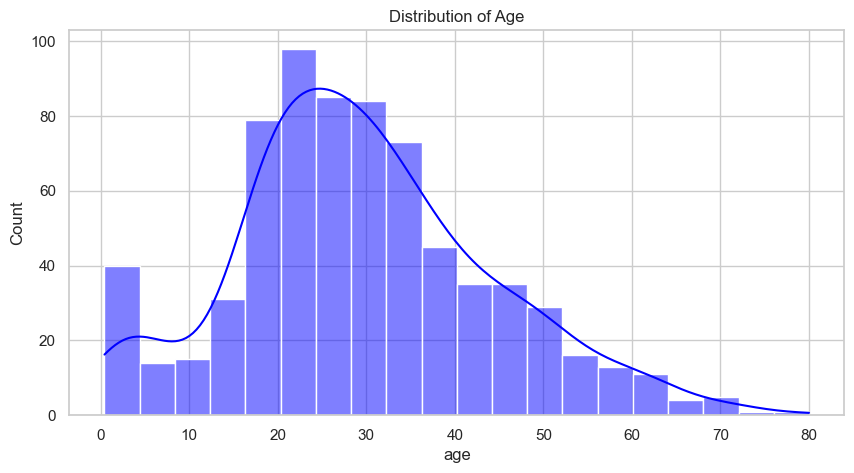

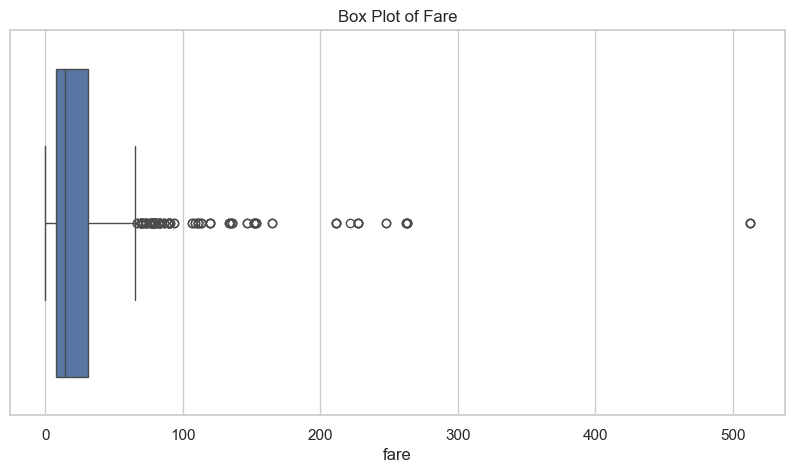

In [2]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Histogram for Age distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['age'].dropna(), kde=True, color='blue')
plt.title('Distribution of Age')
plt.show()

# Box plot for Fare to check for outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['fare'])
plt.title('Box Plot of Fare')
plt.show()

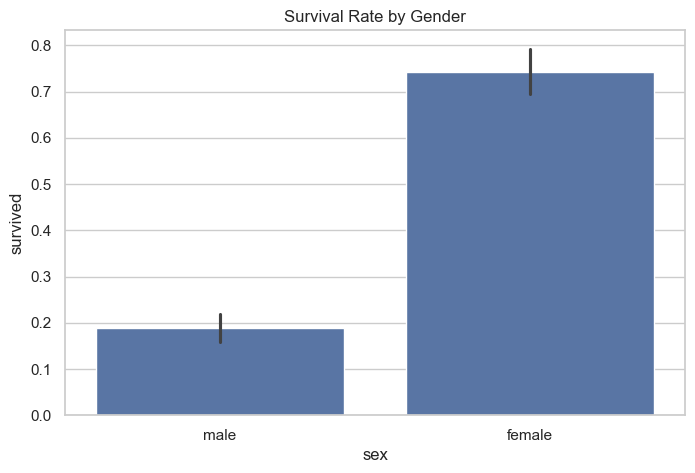

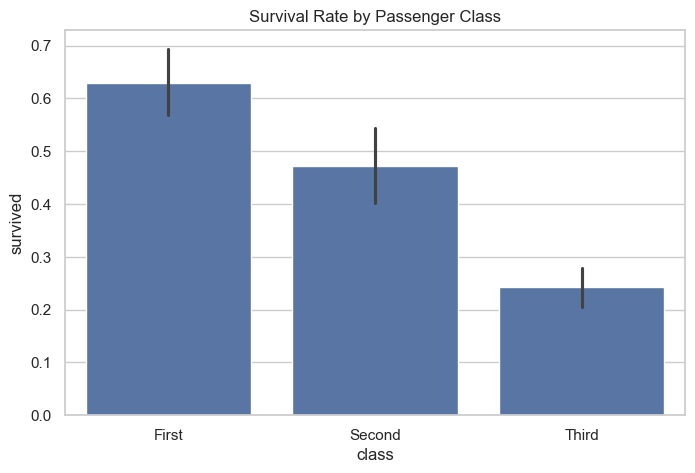

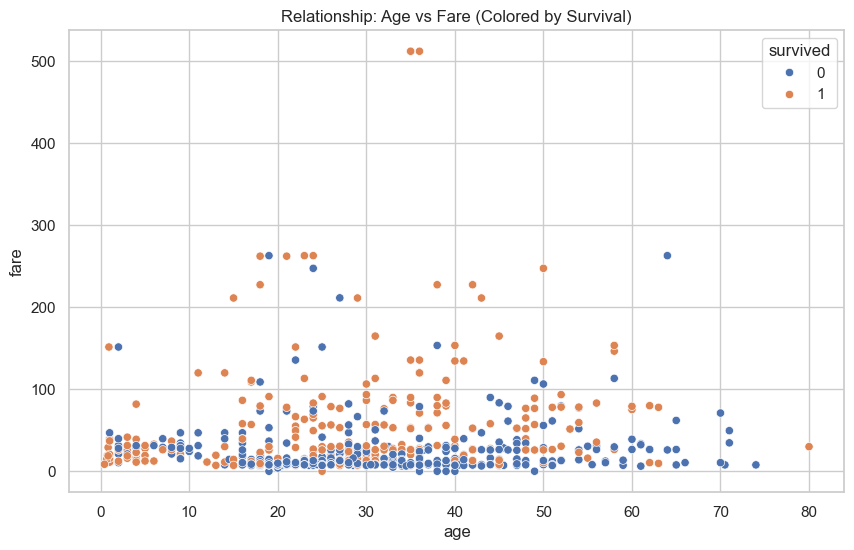

In [3]:
# Bar plot: Survival rate by Sex
plt.figure(figsize=(8, 5))
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

# Bar plot: Survival rate by Class
plt.figure(figsize=(8, 5))
sns.barplot(x='class', y='survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

# Relationship between Age, Fare, and Survival
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title('Relationship: Age vs Fare (Colored by Survival)')
plt.show()

### Data Preprocessing:

In [10]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv('diabetes.csv')

# Identify columns where 0 is actually a missing value
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# Impute using Median (better than mean for skewed health data)
imputer = SimpleImputer(strategy='median')
df[cols_to_fix] = imputer.fit_transform(df[cols_to_fix])

### Building Predictive Models:

In [11]:
from sklearn.model_selection import train_test_split

# Split into Features (X) and Target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- XGBoost Tuning ---
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

# --- LightGBM Tuning ---
lgbm = LGBMClassifier()
lgbm_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}
lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=5, scoring='accuracy')
lgbm_grid.fit(X_train, y_train)
best_lgbm = lgbm_grid.best_estimator_

C:\Users\ibran\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ibran\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ibran\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ibran\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [13]:
!pip install xgboost lightgbm

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.5 MB/s eta 0:00:16
    --------------------------------------- 1.6/101.7 MB 3.9 MB/s eta 0:00:26
    --------------------------------------- 2.4/101.7 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 2.6/101.7 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 3.7/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 3.9/101.7 MB 3.6 MB/s eta 0:00:28
   -- ------------------------------------- 5.2/101.7 MB 3.7 MB/s eta 0:00:27
   -- ------------------------------------- 6.0/101.7 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 6.8/101.7 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 7.6/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.4/101.7 MB 3.7 MB/s eta 0:00:25
   --- ------------------------------------ 9.2/101.7 MB 3.8 MB/s eta 0

In [14]:
import xgboost
import lightgbm
print("XGBoost version:", xgboost.__version__)
print("LightGBM version:", lightgbm.__version__)

XGBoost version: 3.2.0
LightGBM version: 4.6.0


In [16]:
from sklearn.metrics import classification_report, accuracy_score

def show_performance(model, name):
    predictions = model.predict(X_test)
    print(f"Results for {name}:")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
    print(classification_report(y_test, predictions))

# Compare both models
show_performance(best_xgb, "XGBoost")
show_performance(best_lgbm, "LightGBM")

Results for XGBoost:
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

Results for LightGBM:
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.80      0.81      0.80        99
           1       0.65      0.64      0.64        55

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



### Comparative Analysis:

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

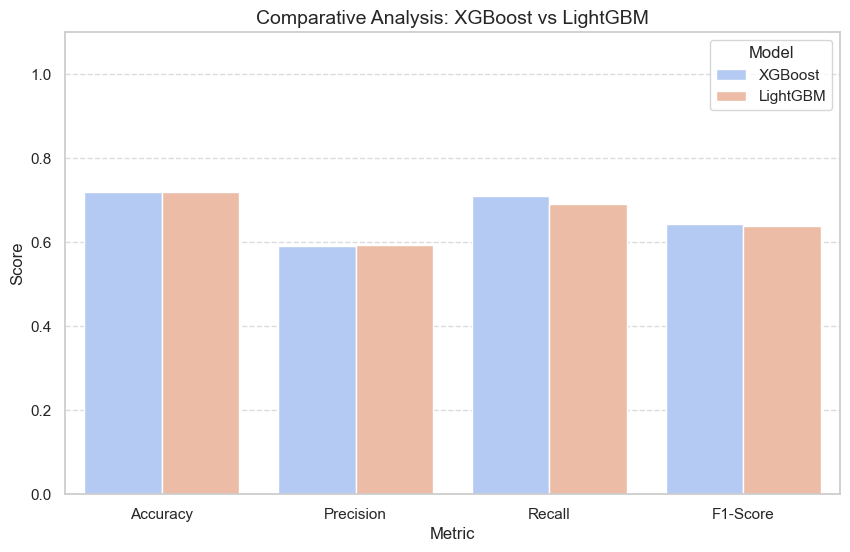

Performance Comparison Table:
   Model  Accuracy  Precision   Recall  F1-Score
 XGBoost  0.720779   0.590909 0.709091  0.644628
LightGBM  0.720779   0.593750 0.690909  0.638655


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

# --- QUICK SETUP (Ensures variables exist to avoid NameError) ---
df = pd.read_csv('diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training models briefly so they are defined
xgb_model = XGBClassifier(eval_metric='logloss').fit(X_train, y_train)
lgbm_model = LGBMClassifier().fit(X_train, y_train)

# --- COMPARATIVE ANALYSIS START ---
# 1. Generate Predictions
xgb_preds = xgb_model.predict(X_test)
lgbm_preds = lgbm_model.predict(X_test)

# 2. Compare Performance Metrics
models = {'XGBoost': xgb_preds, 'LightGBM': lgbm_preds}
results = []

for name, preds in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)

# 3. Visualize Results
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model', palette='coolwarm')
plt.title('Comparative Analysis: XGBoost vs LightGBM', fontsize=14)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Final Comparison Table
print("Performance Comparison Table:")
print(results_df.to_string(index=False))